# Problem Set 7: Progressive Taxation in a Bewley Economy
## Boar-Midrigan (2022, JME) — "Efficient Redistribution"

This notebook solves a heterogeneous-agent model with endogenous labor supply and HSV progressive taxation. We compute:

1. **Steady states** under baseline ($\tau=0.25$, $\xi=0.05$) and reform ($\tau=0.45$, $\xi=0.20$) tax parameters
2. **Transition dynamics** after a one-time unanticipated tax reform using the global backward-forward shooting method
3. **Welfare analysis** with consumption-equivalent variation (CEV) decomposed by value-function terciles

All computations use the `hetmacro` package.

In [22]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'  # macOS Accelerate

import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(0, '../../..')

from hetmacro.models.boar_midrigan import (
    solve_boar_midrigan_ss,
    boar_midrigan_transition,
    compute_welfare_cev,
    welfare_by_tercile,
    firm_prices_from_r,
)
from hetmacro.taxes import hsv_marginal_tax, hsv_average_tax, hsv_post_tax

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
# Figure output directory (macro bible)
FIGDIR = os.path.normpath(os.path.join(
    os.getcwd(), '..', '..', '..', '..', '..', 'Macro Bible',
    'Parts_and_chapters', 'Heterogeneity', 'Standard_Incomplete_Markets', 'figures',
))
os.makedirs(FIGDIR, exist_ok=True)

## 1. The HSV Tax Function

Before solving the model, let's visualize the HSV tax schedule for the baseline and reform parameters.

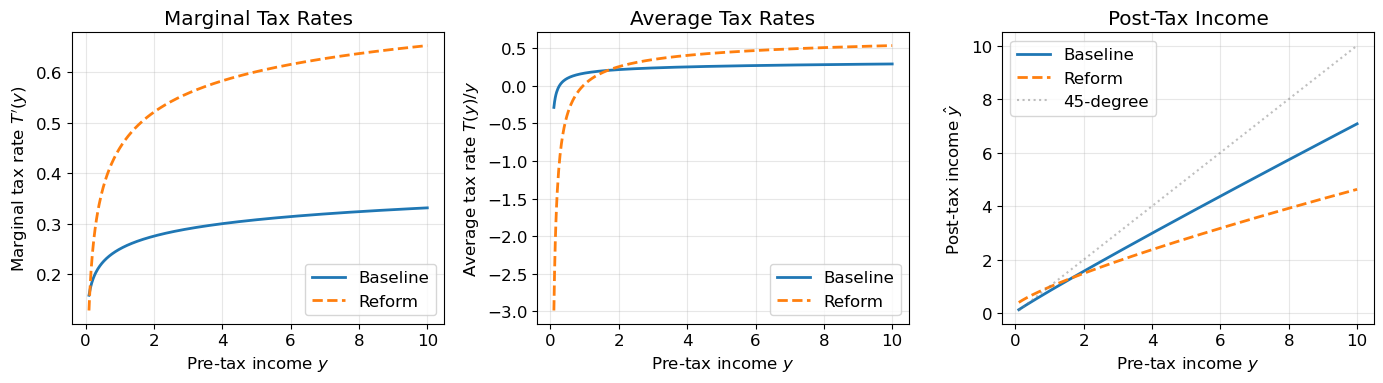

In [23]:
y = np.linspace(0.1, 10, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Marginal tax rates
for tau, xi, label, ls in [(0.25, 0.05, 'Baseline', '-'), (0.45, 0.20, 'Reform', '--')]:
    mtax = hsv_marginal_tax(y, tau, xi)
    axes[0].plot(y, mtax, ls, label=label, lw=2)
axes[0].set_xlabel('Pre-tax income $y$')
axes[0].set_ylabel("Marginal tax rate $T'(y)$")
axes[0].set_title('Marginal Tax Rates')
axes[0].legend()

# Average tax rates
for tau, xi, iota, label, ls in [(0.25, 0.05, 0.04, 'Baseline', '-'), (0.45, 0.20, 0.29, 'Reform', '--')]:
    avg = hsv_average_tax(y, tau, xi, iota)
    axes[1].plot(y, avg, ls, label=label, lw=2)
axes[1].set_xlabel('Pre-tax income $y$')
axes[1].set_ylabel('Average tax rate $T(y)/y$')
axes[1].set_title('Average Tax Rates')
axes[1].legend()

# Post-tax income
for tau, xi, iota, label, ls in [(0.25, 0.05, 0.04, 'Baseline', '-'), (0.45, 0.20, 0.29, 'Reform', '--')]:
    yhat = hsv_post_tax(y, tau, xi, iota)
    axes[2].plot(y, yhat, ls, label=label, lw=2)
axes[2].plot(y, y, ':', color='gray', alpha=0.5, label='45-degree')
axes[2].set_xlabel('Pre-tax income $y$')
axes[2].set_ylabel('Post-tax income $\\hat{y}$')
axes[2].set_title('Post-Tax Income')
axes[2].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_hsv_tax_functions.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 2. Steady State: Baseline Tax ($\tau = 0.25$, $\xi = 0.05$)

In [24]:
t0 = time.time()
ss_old = solve_boar_midrigan_ss(
    n_e=9, n_a=251, a_max=500.0, curvature=3.0,
    rho_e=0.98, sigma_e=0.20,
    beta=0.97, theta=1.5, gamma=2.0,
    alpha=1/3, delta=0.06,
    tau=0.25, xi=0.05, G=0.5,
    r_init=0.02, iota_init=0.20,
    method='shooting', damping=2/3,
    tol=1e-5, max_iter=80,
    verbose=True,
)
print(f'\nTotal time: {time.time()-t0:.1f}s')

Boar-Midrigan Steady State (shooting, r-iota)
iter   ||change||          r       iota
   1     1.77e-01     0.0200     0.2000
   2     1.18e-01     0.0161     0.1411
   3     7.05e-02     0.0166     0.1019
   4     4.43e-02     0.0158     0.0784
   5     2.70e-02     0.0156     0.0636
   6     1.67e-02     0.0154     0.0546
   7     1.03e-02     0.0153     0.0490
   8     6.32e-03     0.0152     0.0456
   9     3.88e-03     0.0152     0.0435
  10     2.39e-03     0.0152     0.0422
  11     1.47e-03     0.0151     0.0414
  12     9.02e-04     0.0151     0.0409
  13     5.54e-04     0.0151     0.0406
  14     3.41e-04     0.0151     0.0404
  15     2.10e-04     0.0151     0.0403
  16     1.29e-04     0.0151     0.0403
  17     7.90e-05     0.0151     0.0402
  18     4.88e-05     0.0151     0.0402
  19     2.96e-05     0.0151     0.0402
  20     1.88e-05     0.0151     0.0402
  21     1.11e-05     0.0151     0.0402
  22     6.33e-06     0.0151     0.0401

Converged in 22 iterations.

Macr

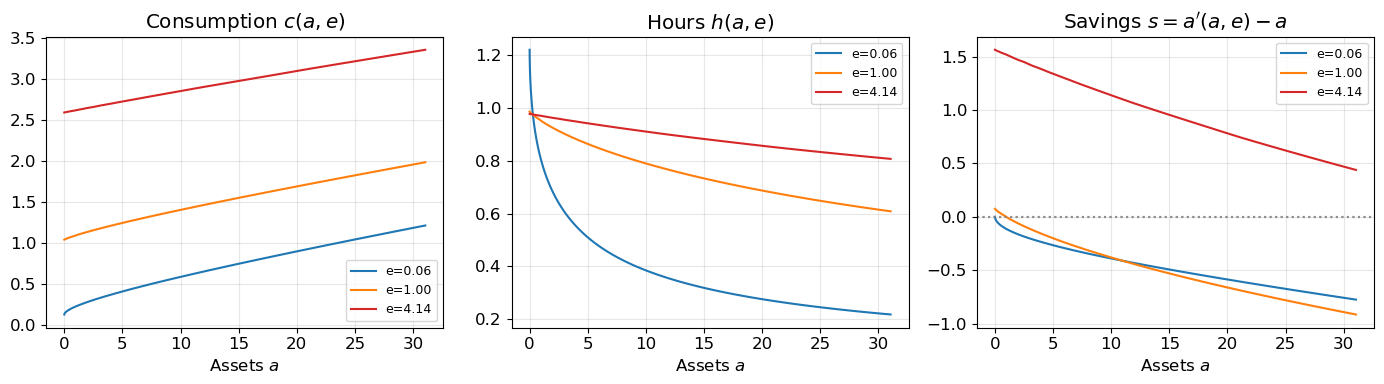

In [25]:
# Policy functions
n_e, n_a = ss_old['n_e'], ss_old['n_a']
a_grid = ss_old['a_grid']
e_grid = ss_old['e_grid']
result = ss_old['result']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
e_indices = [0, n_e//2, n_e//2 + 2]
e_labels = [f'e={e_grid[i]:.2f}' for i in e_indices]
colors = ['tab:blue', 'tab:orange', 'tab:red']

for idx, (ie, label, c) in enumerate(zip(e_indices, e_labels, colors)):
    axes[0].plot(a_grid[:100], result.policy_c[ie, :100], color=c, label=label)
    axes[1].plot(a_grid[:100], result.policy_h[ie, :100], color=c, label=label)
    axes[2].plot(a_grid[:100], result.policy_a[ie, :100] - a_grid[:100], color=c, label=label)
    axes[2].axhline(0, color='gray', alpha=0.5, ls=':')

axes[0].set_title('Consumption $c(a,e)$')
axes[1].set_title('Hours $h(a,e)$')
axes[2].set_title("Savings $s = a'(a,e) - a$")
for ax in axes:
    ax.set_xlabel('Assets $a$')
    ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_policy_functions.pdf'), bbox_inches='tight', dpi=150)
plt.show()

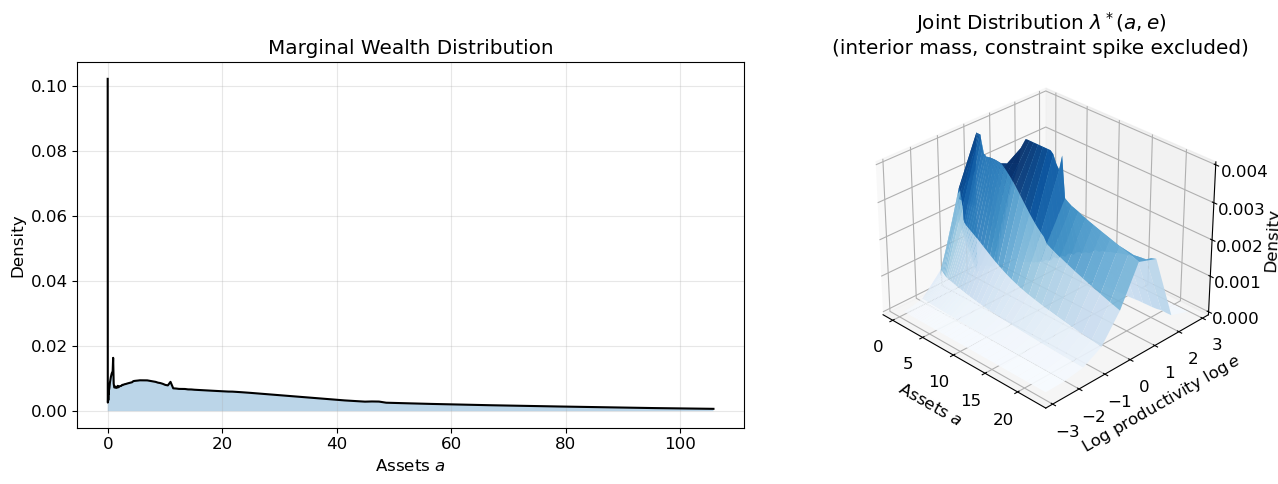

In [26]:
# Stationary distribution
D = ss_old['D']
fig = plt.figure(figsize=(14, 5))

# Marginal wealth distribution (left) — keep full picture including constraint mass
ax0 = fig.add_subplot(1, 2, 1)
wealth_marginal = D.sum(axis=0)
ax0.plot(a_grid[:150], wealth_marginal[:150], 'k-', lw=1.5)
ax0.fill_between(a_grid[:150], wealth_marginal[:150], alpha=0.3)
ax0.set_xlabel('Assets $a$')
ax0.set_ylabel('Density')
ax0.set_title('Marginal Wealth Distribution')
ax0.grid(True, alpha=0.3)

# 3D surface — skip borrowing-constraint spike, log productivity on y-axis
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
a_start = 5          # skip first points where constraint mass dominates
a_end   = 90
D_plot  = D[:, a_start:a_end].copy()
D_plot  = np.minimum(D_plot, np.percentile(D_plot, 97))  # soft clip top 3% of mass

log_e = np.log(e_grid)
A, LE = np.meshgrid(a_grid[a_start:a_end], log_e)
ax1.plot_surface(A, LE, D_plot, cmap='Blues', edgecolor='none', alpha=0.92)
ax1.set_xlabel('Assets $a$')
ax1.set_ylabel('Log productivity $\\log e$')
ax1.set_zlabel('Density')
ax1.set_title('Joint Distribution $\\lambda^*(a, e)$\n(interior mass, constraint spike excluded)')
ax1.view_init(elev=30, azim=-45)

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_stationary_distribution.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 3. Steady State: Reform Tax ($\tau = 0.45$, $\xi = 0.20$)

The reform makes the tax system substantially more progressive. We use the $(K, L, \iota)$ formulation (`shooting_KLiota`) rather than the $(r, \iota)$ formulation, since the $r$-mapping is unstable for highly progressive tax schedules. The $(K, L)$ mapping is contractive because higher capital supply lowers $r$, which dampens savings incentives.

In [27]:
t0 = time.time()
ss_new = solve_boar_midrigan_ss(
    n_e=9, n_a=251, a_max=500.0, curvature=3.0,
    rho_e=0.98, sigma_e=0.20,
    beta=0.97, theta=1.5, gamma=2.0,
    alpha=1/3, delta=0.06,
    tau=0.45, xi=0.20, G=0.5,
    r_init=ss_old['r'], iota_init=ss_old['iota'],
    K_init=ss_old['K'], L_init=ss_old['L'],
    method='shooting', damping=2/3,
    tol=1e-4, max_iter=100,
    verbose=True,
)
print(f'\nTotal time: {time.time()-t0:.1f}s')


Boar-Midrigan Steady State (shooting, r-iota)
iter   ||change||          r       iota
   1     3.55e-01     0.0151     0.0401
   2     3.13e-01     0.0487     0.1535
   3     3.84e-02     0.0323     0.2566
   4     7.20e-02     0.0431     0.2635
   5     2.03e-02     0.0357     0.2863
   6     2.72e-02     0.0412     0.2824
   7     1.50e-02     0.0371     0.2905
   8     1.28e-02     0.0402     0.2866
   9     9.36e-03     0.0379     0.2901
  10     6.71e-03     0.0396     0.2875
  11     5.41e-03     0.0383     0.2894
  12     3.69e-03     0.0392     0.2878
  13     3.05e-03     0.0385     0.2888
  14     2.09e-03     0.0391     0.2880
  15     1.68e-03     0.0387     0.2885
  16     1.14e-03     0.0390     0.2881
  17     8.90e-04     0.0387     0.2884
  18     6.22e-04     0.0389     0.2881
  19     5.06e-04     0.0388     0.2883
  20     3.64e-04     0.0389     0.2881
  21     2.85e-04     0.0388     0.2882
  22     2.20e-04     0.0388     0.2882
  23     1.71e-04     0.0388     0

In [28]:
# Comparison table
print('=' * 65)
print(f'{"":>20s} {"Baseline":>12s} {"Reform":>12s} {"log change":>12s}')
print('=' * 65)
for k in ['Y', 'C', 'K', 'L']:
    logch = np.log(ss_new[k] / ss_old[k])
    print(f'{k:>20s} {ss_old[k]:12.4f} {ss_new[k]:12.4f} {logch:12.4f}')
print('-' * 65)
print(f'{"r (% p.a.)":>20s} {ss_old["r"]*400:12.4f} {ss_new["r"]*400:12.4f}')
print(f'{"W":>20s} {ss_old["W"]:12.4f} {ss_new["W"]:12.4f}')
print(f'{"iota":>20s} {ss_old["iota"]:12.4f} {ss_new["iota"]:12.4f}')
print('-' * 65)
print('Moments:')
for k in ['wealth_to_income', 'gini_wealth', 'gini_income']:
    print(f'  {k:>22s} {ss_old["moments"][k]:10.3f} {ss_new["moments"][k]:10.3f}')
print('-' * 65)
print('Factor shares:')
for ss in [ss_old, ss_new]:
    wL = ss['W'] * ss['L']
    rK = ss['r'] * ss['K']
    lab_share = wL / (wL + rK)
    tag = 'Baseline' if ss is ss_old else 'Reform  '
    print(f'  {tag}  wL/(wL+rK) = {lab_share:.4f}')
print('=' * 65)

                         Baseline       Reform   log change
                   Y       2.8851       2.2737      -0.2381
                   C       1.6169       1.3138      -0.2076
                   K      12.8029       7.6669      -0.5128
                   L       1.3696       1.2382      -0.1008
-----------------------------------------------------------------
          r (% p.a.)       6.0461      15.5254
                   W       1.4044       1.2244
                iota       0.0401       0.2882
-----------------------------------------------------------------
Moments:
        wealth_to_income      6.048      4.227
             gini_wealth      0.728      0.685
             gini_income      0.490      0.511
-----------------------------------------------------------------
Factor shares:
  Baseline  wL/(wL+rK) = 0.9086
  Reform    wL/(wL+rK) = 0.8359


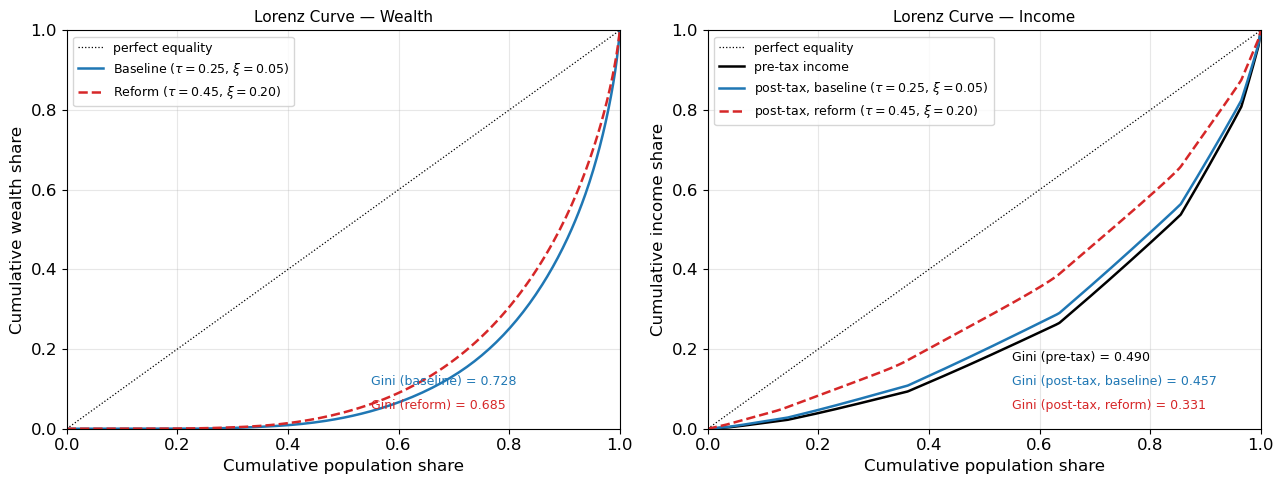

In [29]:
# Lorenz curves: wealth (left) and income redistribution (right)
def lorenz_curve(values, weights):
    order = np.argsort(values)
    v_sorted = values[order]; w_sorted = weights[order]
    cum_pop = np.cumsum(w_sorted) / np.sum(w_sorted)
    cum_val = np.cumsum(v_sorted * w_sorted); cum_val = cum_val / cum_val[-1]
    return np.concatenate([[0.0], cum_pop]), np.concatenate([[0.0], cum_val])

def gini(values, weights):
    order = np.argsort(values)
    v = values[order]; w = weights[order]; w = w / w.sum()
    cum_w = np.cumsum(w)
    return 1.0 - float(np.sum(w * v / np.sum(v * w) * (w + 2.0 * (1.0 - cum_w))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Wealth Lorenz ──────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k:', lw=0.9, label='perfect equality')

for ss, label, ls, color in [
    (ss_old, 'Baseline ($\\tau=0.25$, $\\xi=0.05$)', '-',  'tab:blue'),
    (ss_new, 'Reform ($\\tau=0.45$, $\\xi=0.20$)',   '--', 'tab:red'),
]:
    a_flat = np.tile(ss['a_grid'], ss['n_e'])
    a_shifted = a_flat - a_flat.min()
    cp, cv = lorenz_curve(a_shifted, ss['D_flat'])
    ax.plot(cp, cv, ls=ls, color=color, lw=1.8, label=label)

for ss, ypos in [(ss_old, 0.11), (ss_new, 0.05)]:
    g = ss['moments']['gini_wealth']
    lbl = 'Baseline' if ss is ss_old else 'Reform'
    clr = 'tab:blue' if ss is ss_old else 'tab:red'
    ax.text(0.55, ypos, f'Gini ({lbl.lower()}) = {g:.3f}',
            transform=ax.transAxes, fontsize=9, color=clr)

ax.set_title('Lorenz Curve — Wealth', fontsize=11)
ax.set_xlabel('Cumulative population share'); ax.set_ylabel('Cumulative wealth share')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)

# ── Right: Income Lorenz (pre-tax + post-tax before/after reform) ────
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k:', lw=0.9, label='perfect equality')

y_pre = np.maximum(ss_old['y'], 0.0)
cp, cv = lorenz_curve(y_pre, ss_old['D_flat'])
ax.plot(cp, cv, 'k-', lw=1.8, label='pre-tax income')
g_pre = gini(y_pre, ss_old['D_flat'])

y_post_old = np.maximum(ss_old['yhat'], 0.0)
cp, cv = lorenz_curve(y_post_old, ss_old['D_flat'])
ax.plot(cp, cv, color='tab:blue', ls='-', lw=1.8,
        label='post-tax, baseline ($\\tau=0.25$, $\\xi=0.05$)')
g_post_old = gini(y_post_old, ss_old['D_flat'])

y_post_new = np.maximum(ss_new['yhat'], 0.0)
cp, cv = lorenz_curve(y_post_new, ss_new['D_flat'])
ax.plot(cp, cv, color='tab:red', ls='--', lw=1.8,
        label='post-tax, reform ($\\tau=0.45$, $\\xi=0.20$)')
g_post_new = gini(y_post_new, ss_new['D_flat'])

ax.text(0.55, 0.17, f'Gini (pre-tax) = {g_pre:.3f}',
        transform=ax.transAxes, fontsize=9, color='k')
ax.text(0.55, 0.11, f'Gini (post-tax, baseline) = {g_post_old:.3f}',
        transform=ax.transAxes, fontsize=9, color='tab:blue')
ax.text(0.55, 0.05, f'Gini (post-tax, reform) = {g_post_new:.3f}',
        transform=ax.transAxes, fontsize=9, color='tab:red')

ax.set_title('Lorenz Curve — Income', fontsize=11)
ax.set_xlabel('Cumulative population share'); ax.set_ylabel('Cumulative income share')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_lorenz_curves.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 4. Transition Dynamics — Global Method

We compute the transition path after the tax reform using backward-forward shooting over $T = 200$ periods. The `r_iota` method updates $(r_t, \iota_t)$ paths directly: guess $r_t$, derive $W_t$ from firm FOCs, solve households backward, simulate distribution forward, compute implied $r_t$ from aggregates, and damp-update. Step $= 1/3$ (standard in the Virgiliu Midrigan pedagogical code) converges monotonically in $\sim 20$ iterations.

Boar-Midrigan Transition Dynamics (method=r_iota)
iter          err        |dr|       |di|
   1     2.64e-01    1.48e-02   2.64e-01
   2     1.51e-01    9.04e-03   1.51e-01
   3     9.03e-02    6.04e-03   9.03e-02
   4     5.45e-02    4.06e-03   5.45e-02
   5     3.36e-02    2.73e-03   3.36e-02
   6     2.09e-02    1.84e-03   2.09e-02
   7     1.32e-02    1.23e-03   1.32e-02
   8     8.42e-03    8.31e-04   8.42e-03
   9     5.42e-03    5.59e-04   5.42e-03
  10     3.51e-03    3.77e-04   3.51e-03
  11     2.29e-03    2.54e-04   2.29e-03
  12     1.50e-03    1.72e-04   1.50e-03
  13     9.47e-04    1.24e-04   9.47e-04
  14     7.05e-04    1.36e-04   7.05e-04
  15     4.25e-04    6.57e-05   4.25e-04
  16     2.91e-04    3.49e-05   2.91e-04
  17     1.91e-04    2.35e-05   1.91e-04
  18     1.29e-04    1.57e-05   1.29e-04
  19     1.06e-04    1.50e-05   1.06e-04
  20     7.80e-05    1.24e-05   7.80e-05

Converged in 20 iterations.


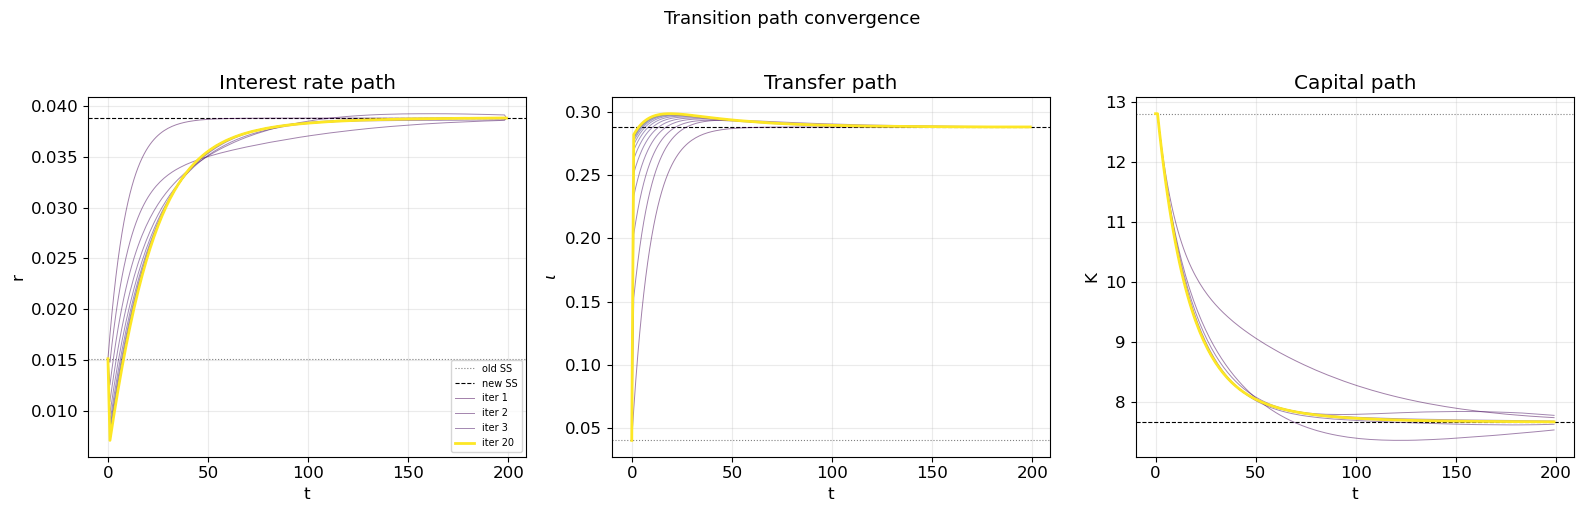


Total time: 37.8s


In [30]:
t0 = time.time()
trans = boar_midrigan_transition(
    ss_old, ss_new,
    T=200, damping=2/3, tol=1e-4, max_iter=50,
    method='r_iota', plot_iterations=True,
    verbose=True,
)
print(f'\nTotal time: {time.time()-t0:.1f}s')

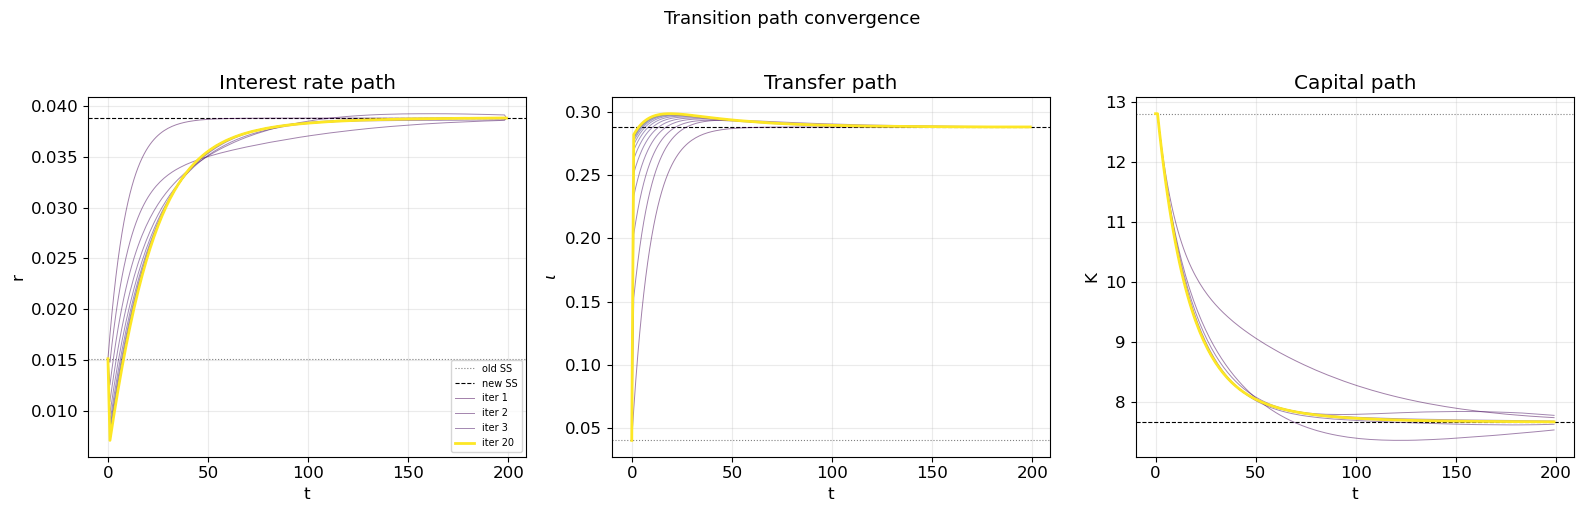

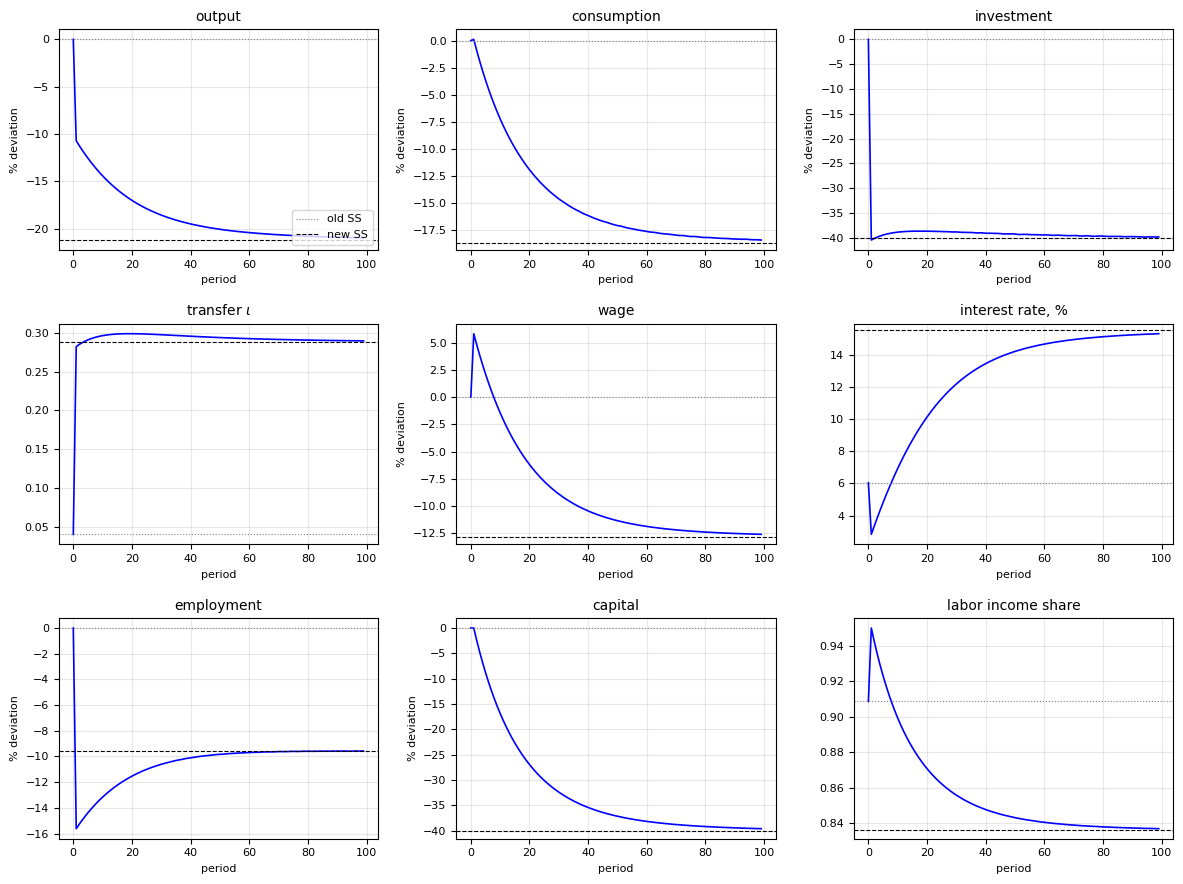

In [31]:
# IRF-style transition paths (3×3 grid, % deviation from old SS)
T_plot = min(100, trans['T'])
t = np.arange(T_plot)

delta = ss_old['delta']

# Investment: I_t = K_{t+1} - (1-δ)·K_t
Kt_arr = trans['Kt']
It = np.diff(Kt_arr) + delta * Kt_arr[:-1]   # length T-1
I_old = delta * ss_old['K']
I_new = delta * ss_new['K']

# Labor income share along path
Wt_arr = trans['Wt'][:T_plot]
Lt_arr = trans['Lt'][:T_plot]
rt_arr = trans['rt'][:T_plot]
Kt_p   = trans['Kt'][:T_plot]
lab_share_t = (Wt_arr * Lt_arr) / (Wt_arr * Lt_arr + rt_arr * Kt_p)
lab_share_old = ss_old['W'] * ss_old['L'] / (ss_old['W'] * ss_old['L'] + ss_old['r'] * ss_old['K'])
lab_share_new = ss_new['W'] * ss_new['L'] / (ss_new['W'] * ss_new['L'] + ss_new['r'] * ss_new['K'])

def pct(x, base):
    return (x / base - 1.0) * 100.0

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

# Each entry: (ax, path, old_ss_val, new_ss_val, title, mode)
# mode='pct' => % deviation; mode='level' => plot in levels
specs = [
    (axes[0,0], trans['Yt'][:T_plot],      ss_old['Y'],    ss_new['Y'],    'output',             'pct'),
    (axes[0,1], trans['Ct'][:T_plot],      ss_old['C'],    ss_new['C'],    'consumption',        'pct'),
    (axes[0,2], It[:T_plot],               I_old,          I_new,          'investment',         'pct'),
    (axes[1,0], trans['iotat'][:T_plot],   ss_old['iota'], ss_new['iota'], 'transfer $\\iota$',  'level'),
    (axes[1,1], trans['Wt'][:T_plot],      ss_old['W'],    ss_new['W'],    'wage',               'pct'),
    (axes[1,2], trans['rt'][:T_plot]*400,  ss_old['r']*400, ss_new['r']*400, 'interest rate, %', 'level'),
    (axes[2,0], trans['Lt'][:T_plot],      ss_old['L'],    ss_new['L'],    'employment',         'pct'),
    (axes[2,1], trans['Kt'][:T_plot],      ss_old['K'],    ss_new['K'],    'capital',            'pct'),
    (axes[2,2], lab_share_t,               lab_share_old,  lab_share_new,  'labor income share', 'level'),
]

for ax, path, v_old, v_new, title, mode in specs:
    if mode == 'pct':
        ax.plot(t, pct(path, v_old), 'b-', lw=1.2)
        ax.axhline(0,                color='gray', ls=':', lw=0.8)
        ax.axhline(pct(v_new, v_old), color='k',   ls='--', lw=0.8)
        ax.set_ylabel('% deviation', fontsize=8)
    else:
        ax.plot(t, path, 'b-', lw=1.2)
        ax.axhline(v_old, color='gray', ls=':', lw=0.8)
        ax.axhline(v_new, color='k',   ls='--', lw=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('period', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

# Shared legend for dashed/dotted reference lines
axes[0,0].plot([], [], color='gray', ls=':', lw=0.8, label='old SS')
axes[0,0].plot([], [], color='k',   ls='--', lw=0.8, label='new SS')
axes[0,0].legend(fontsize=8, loc='lower right')

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_transition_irfs.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Welfare Analysis

We compute the consumption-equivalent variation (CEV) using the value functions from $t=1$ (immediately after the reform announcement) evaluated at the old steady-state distribution. The analysis decomposes welfare by value-function terciles: bottom third (most constrained), middle third, and top third (wealthiest).

In [32]:
# Welfare: compare old SS value function with t=1 value function after reform
v_old = trans['vt'][:, 0]   # old SS value function
v_new = trans['vt'][:, 1]   # value function at t=1 (after reform announcement)
D_old = ss_old['D_flat']
beta = ss_old['beta']
theta = ss_old['theta']

welfare = welfare_by_tercile(v_old, v_new, D_old, beta, theta)

print('Welfare Gains (CEV)')
print('=' * 45)
for group in ['all', 'bottom', 'middle', 'top']:
    omega_old, omega_new, cev = welfare[group]
    print(f'  {group:>8s}:  CEV = {cev:+.4f}  ({cev*100:+.2f}%)')
print('=' * 45)

Welfare Gains (CEV)
       all:  CEV = +0.1946  (+19.46%)
    bottom:  CEV = +0.4122  (+41.22%)
    middle:  CEV = +0.1104  (+11.04%)
       top:  CEV = -0.0144  (-1.44%)


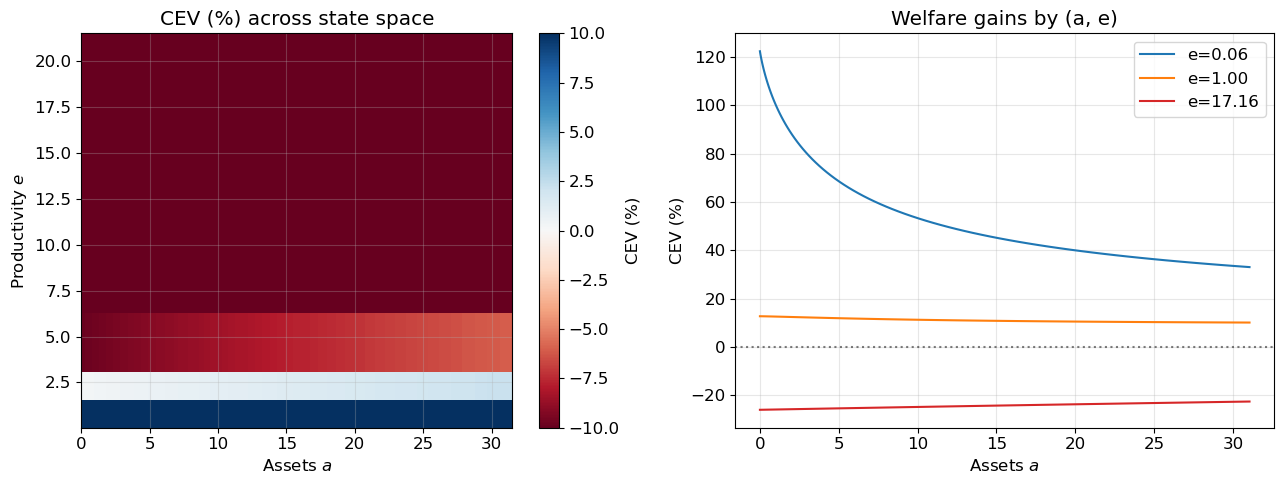

In [33]:
# Welfare gains across the state space
n_e, n_a = ss_old['n_e'], ss_old['n_a']
a_grid = ss_old['a_grid']
e_grid = ss_old['e_grid']

# CEV at each (a, e) point
if abs(theta - 1.0) < 1e-12:
    omega_old_2d = np.exp((1 - beta) * v_old.reshape(n_e, n_a))
    omega_new_2d = np.exp((1 - beta) * v_new.reshape(n_e, n_a))
else:
    omega_old_2d = ((1 - beta) * (1 - theta) * v_old.reshape(n_e, n_a)) ** (1 / (1 - theta))
    omega_new_2d = ((1 - beta) * (1 - theta) * v_new.reshape(n_e, n_a)) ** (1 / (1 - theta))

cev_2d = omega_new_2d / omega_old_2d - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
im = axes[0].pcolormesh(a_grid[:100], e_grid, cev_2d[:, :100] * 100,
                         shading='auto', cmap='RdBu', vmin=-10, vmax=10)
axes[0].set_xlabel('Assets $a$')
axes[0].set_ylabel('Productivity $e$')
axes[0].set_title('CEV (%) across state space')
plt.colorbar(im, ax=axes[0], label='CEV (%)')

# By productivity, averaging over assets
for ie, c in zip([0, n_e//2, n_e-1], colors):
    axes[1].plot(a_grid[:100], cev_2d[ie, :100] * 100, color=c,
                 label=f'e={e_grid[ie]:.2f}', lw=1.5)
axes[1].axhline(0, color='k', ls=':', alpha=0.5)
axes[1].set_xlabel('Assets $a$')
axes[1].set_ylabel('CEV (%)')
axes[1].set_title('Welfare gains by (a, e)')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_welfare_analysis.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Consumption and Hours by Tercile Group

We track average consumption and hours for the bottom, middle, and top terciles of the initial value-function distribution, both under the reform and under the status-quo counterfactual.

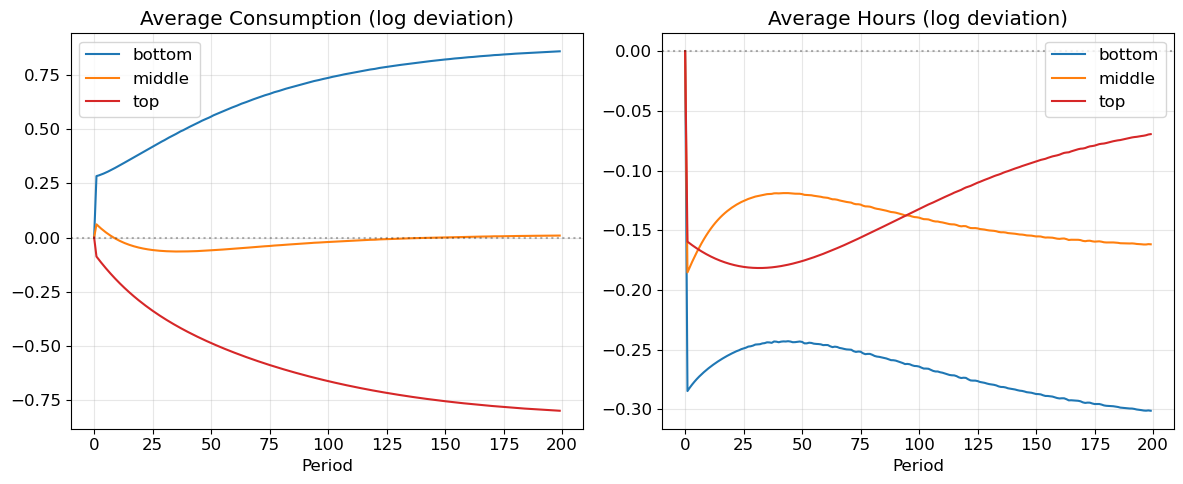

In [34]:
from hetmacro.models.boar_midrigan import _weighted_percentile
from hetmacro.forward import forward_iteration
from hetmacro.interpolation import get_lottery

n_s = n_e * n_a
T_sim = min(200, trans['T'])

# Define tercile groups based on old SS value function
v_old_flat = ss_old['v']
D_old_flat = ss_old['D_flat']

p33 = _weighted_percentile(v_old_flat, 100/3, D_old_flat)
p67 = _weighted_percentile(v_old_flat, 200/3, D_old_flat)

bot = v_old_flat <= p33
mid = (~bot) & (v_old_flat <= p67)
top = v_old_flat > p67

# Initialize group distributions (reform path)
groups = {'bottom': bot, 'middle': mid, 'top': top}
C_groups = {g: np.zeros(T_sim) for g in groups}
H_groups = {g: np.zeros(T_sim) for g in groups}

# Track distributions for each group under reform
D_g = {}
for name, mask in groups.items():
    d = D_old_flat.copy()
    d[~mask] = 0.0
    if d.sum() > 0:
        d = d / d.sum()
    D_g[name] = d.reshape(n_e, n_a)

for t_idx in range(T_sim):
    for name in groups:
        D_t = D_g[name]
        D_t_flat = D_t.ravel()
        C_groups[name][t_idx] = float(np.sum(D_t_flat * trans['ct'][:, t_idx]))
        H_groups[name][t_idx] = float(np.sum(D_t_flat * trans['ht'][:, t_idx]))
        
        # Forward step (except last period)
        if t_idx < T_sim - 1:
            kp_2d = trans['kprimet'][:, t_idx].reshape(n_e, n_a)
            a_i, a_pi = get_lottery(kp_2d, a_grid)
            D_g[name] = forward_iteration(D_t, ss_old['Pi'], a_i, a_pi)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
t = np.arange(T_sim)
group_colors = {'bottom': 'tab:blue', 'middle': 'tab:orange', 'top': 'tab:red'}

for name, c in group_colors.items():
    axes[0].plot(t, np.log(C_groups[name] / C_groups[name][0]), color=c, lw=1.5, label=name)
    axes[1].plot(t, np.log(H_groups[name] / H_groups[name][0]), color=c, lw=1.5, label=name)

axes[0].set_title('Average Consumption (log deviation)')
axes[1].set_title('Average Hours (log deviation)')
for ax in axes:
    ax.set_xlabel('Period')
    ax.axhline(0, color='k', ls=':', alpha=0.3)
    ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'bm_tercile_analysis.pdf'), bbox_inches='tight', dpi=150)
plt.show()